In [106]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

from category_encoders import JamesSteinEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from datetime import date
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


In [107]:
data = pd.read_csv("./fraudTrain.csv", index_col=0)




In [108]:
data.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [109]:
data.drop(columns=["first","last"] , inplace=True)
data['distance_km'] = haversine_vectorized(data['lat'], data['long'], data['merch_lat'], data['merch_long'])
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,distance_km
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,78.597568
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,30.212176
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,108.206083
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,95.673231
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,77.556744


In [110]:
data.nunique()


trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
distance_km              1296675
dtype: int64

In [111]:
data['distance_km'] = haversine_vectorized(data['lat'], data['long'], data['merch_lat'], data['merch_long'])

In [112]:
data.drop(columns=["trans_num","unix_time","merch_lat","merch_long"] , inplace=True)

In [113]:
data.columns


Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop',
       'job', 'dob', 'is_fraud', 'distance_km'],
      dtype='str')

In [114]:
data.dtypes

trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
is_fraud                   int64
distance_km              float64
dtype: object

In [115]:

fraud = data[data['is_fraud'] == 1]
non_fraud = data[data['is_fraud'] == 0]

# 2. Randomly sample non-fraud to match the number of fraud cases (50/50 ratio)
# You can also use 'n=len(fraud) * 10' for a 10/90 ratio
non_fraud_downsampled = non_fraud.sample(n=len(fraud), random_state=42)

# 3. Combine back into a small, balanced plotting dataframe
plot_df = pd.concat([fraud, non_fraud_downsampled]).sample(frac=1) 

data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,is_fraud,distance_km
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0,78.597568
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,0,30.212176
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,0,108.206083
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,0,95.673231
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,0,77.556744


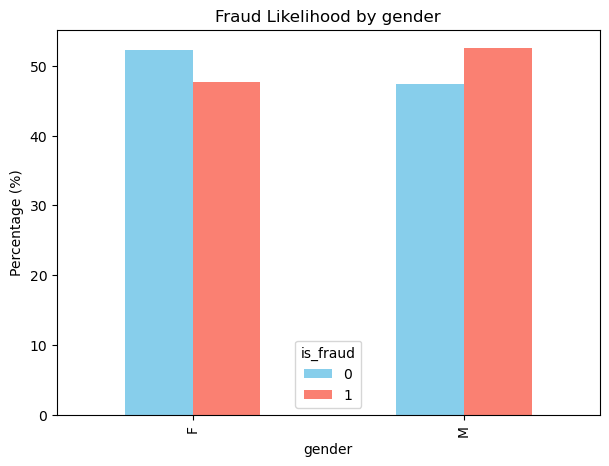

In [116]:


def plot_bar(df , col , width=7):
    counts = pd.crosstab(df[col], df['is_fraud'])
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    percentages.plot.bar(stacked=False, color=['skyblue', 'salmon'],figsize=(width,5))
    plt.ylabel('Percentage (%)')
    plt.title(f'Fraud Likelihood by {col}')
    plt.show()
  

def sample_and_plot(df , col , width=7 , nsamples=100):
    top_fraud_col = df[col].value_counts().nlargest(nsamples).index
    filtered_df = df[plot_df[col].isin(top_fraud_col)]
    plot_bar(filtered_df,col,width)

plot_bar(plot_df ,"gender")

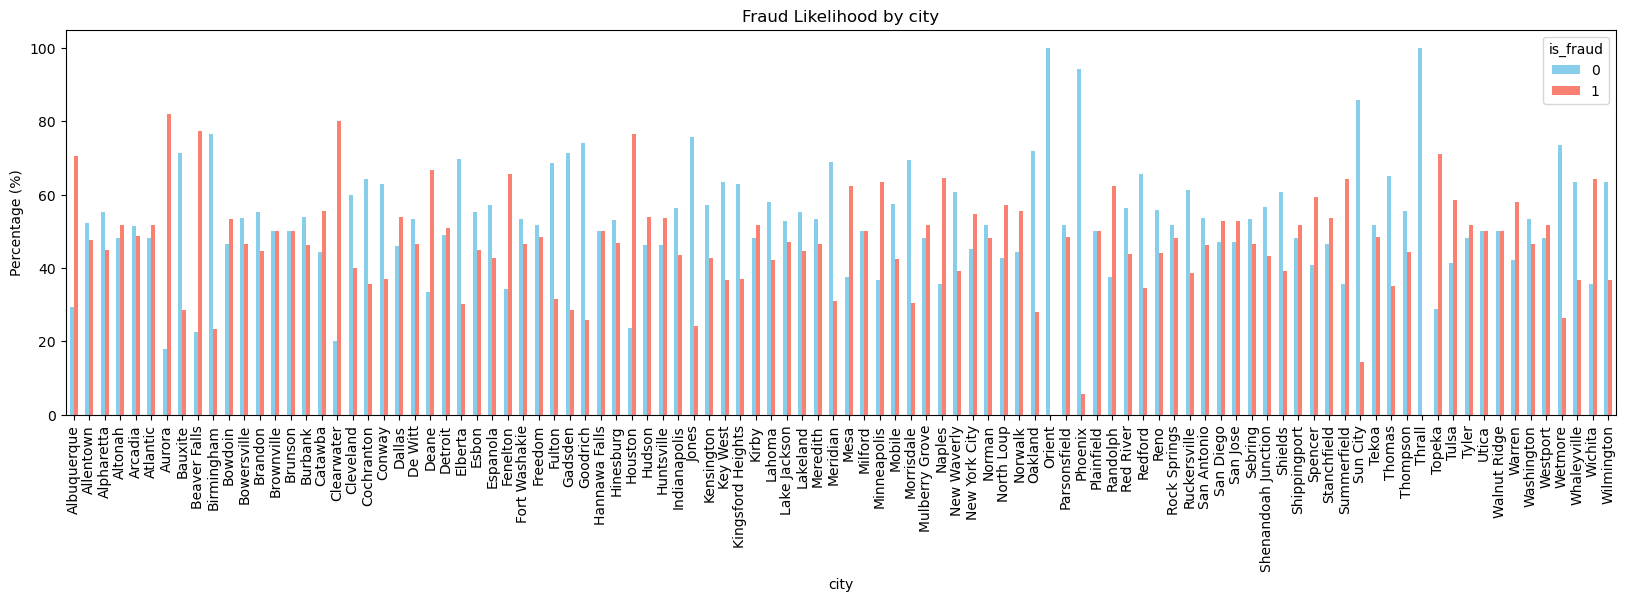

In [117]:

sample_and_plot(plot_df ,'city',20,100)

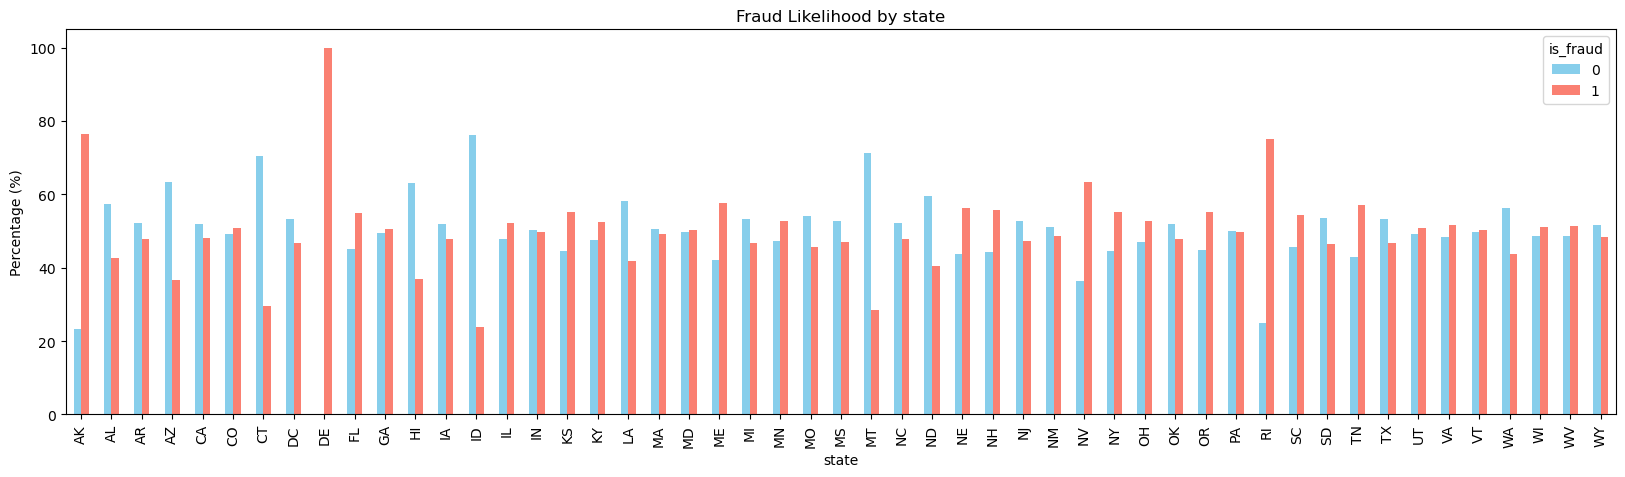

In [118]:

sample_and_plot(plot_df ,'state',20,100)

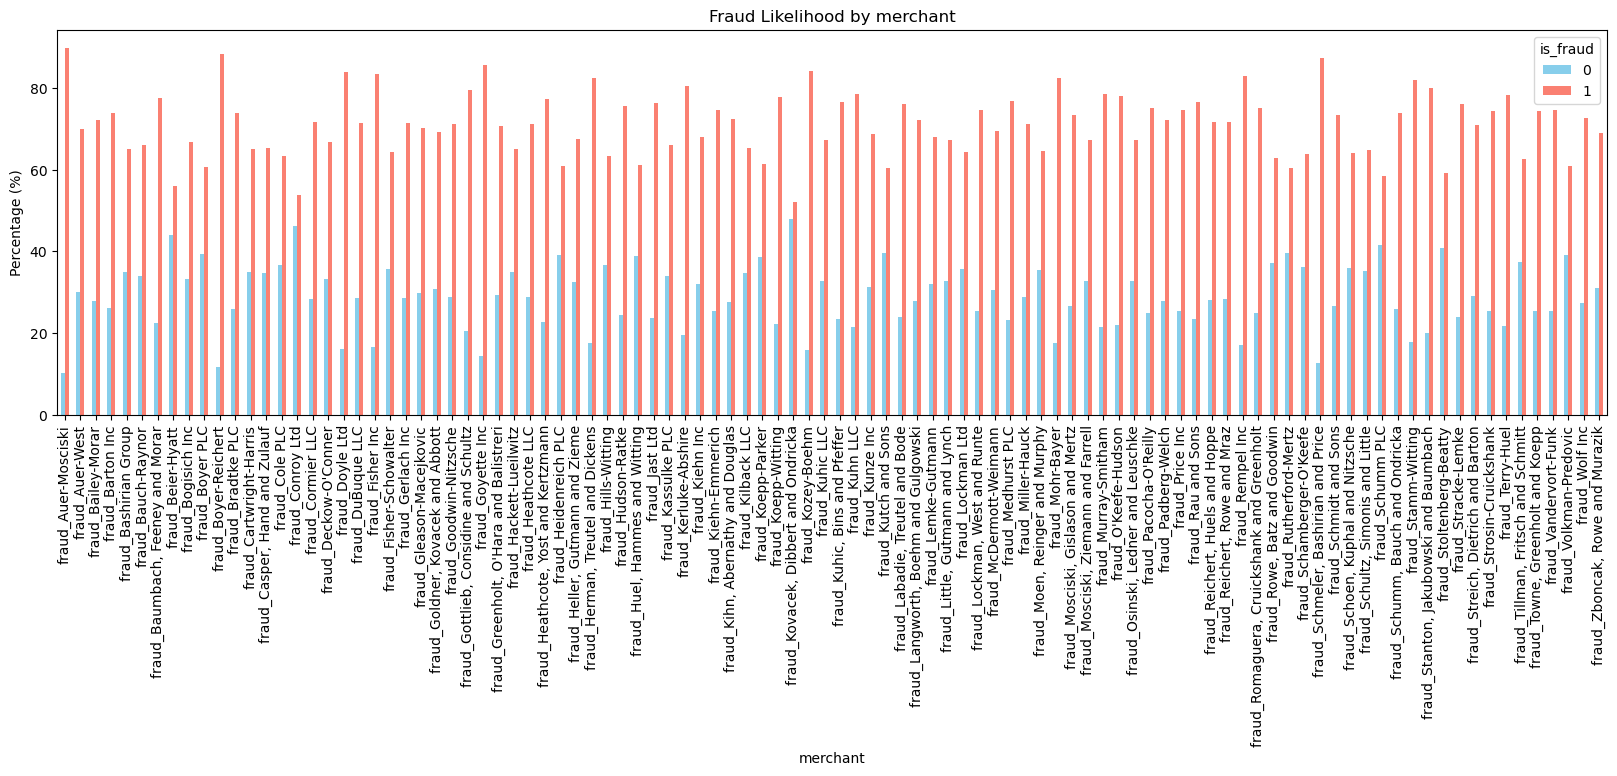

In [119]:

sample_and_plot(plot_df ,'merchant',20,100)

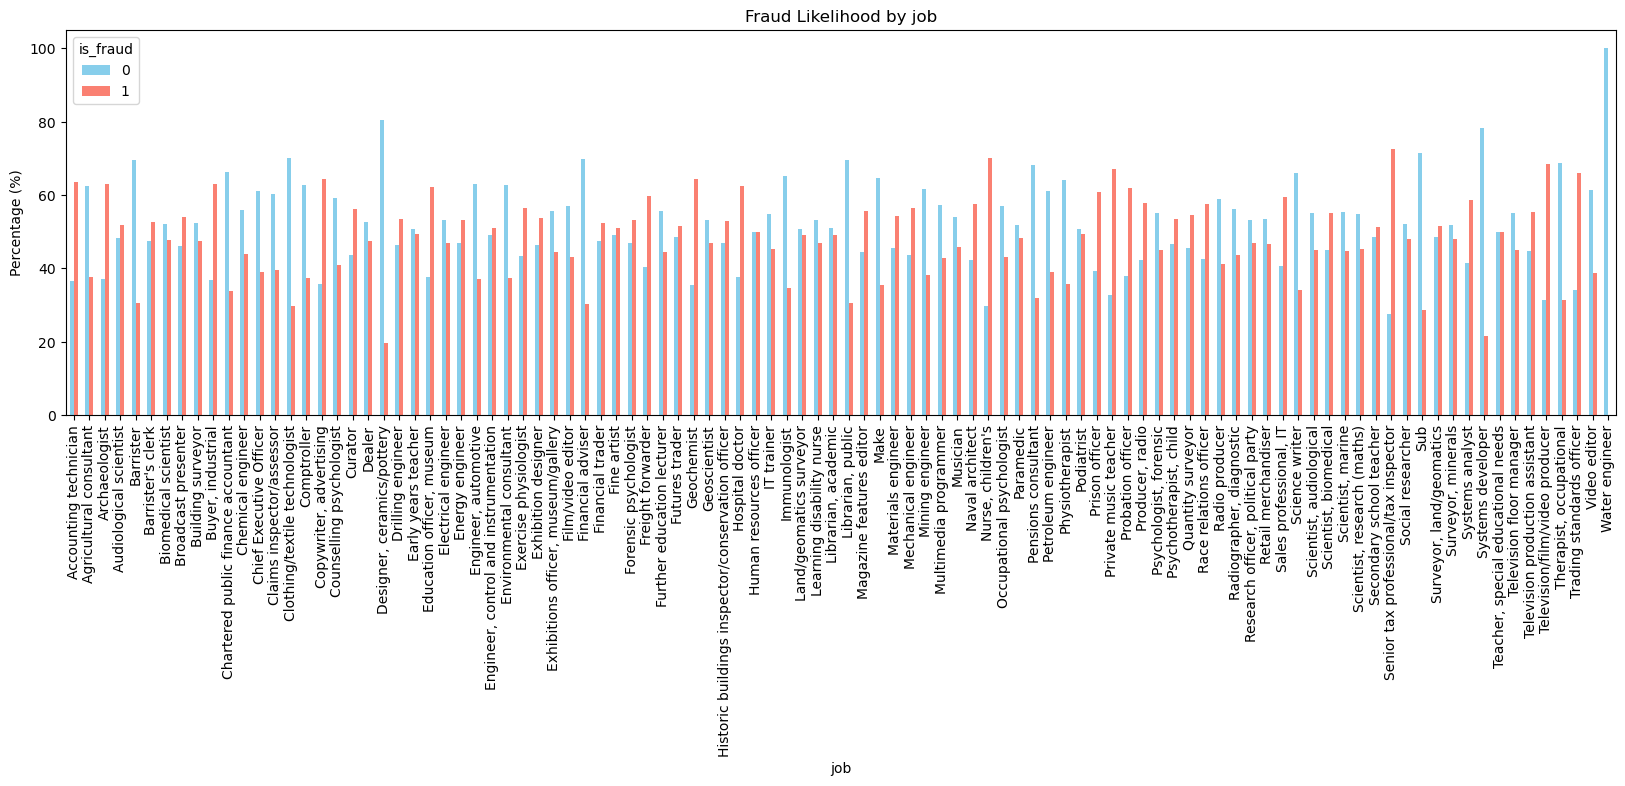

In [120]:

sample_and_plot(plot_df ,'job',20,100)

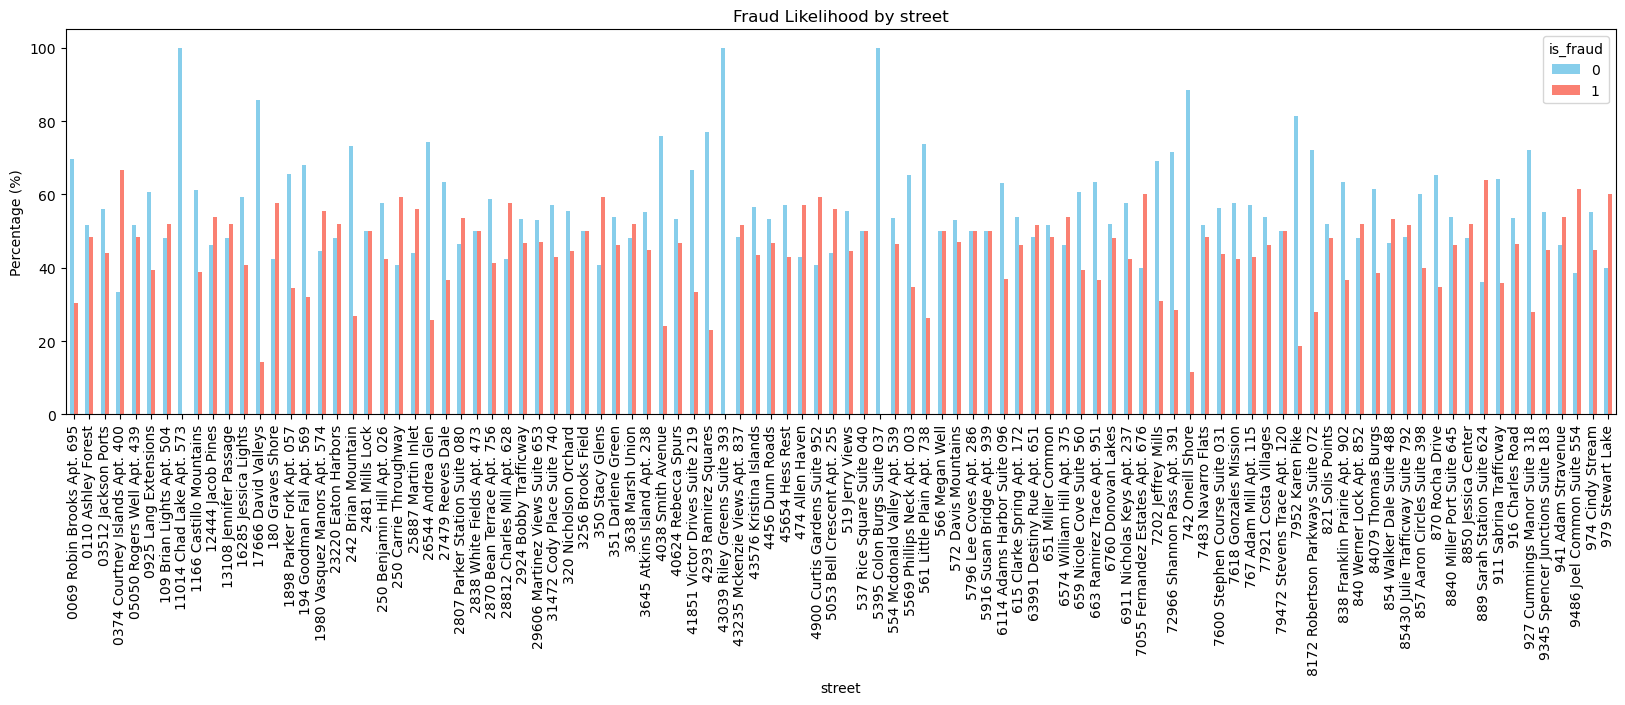

In [121]:
sample_and_plot(plot_df ,'street',20,100)

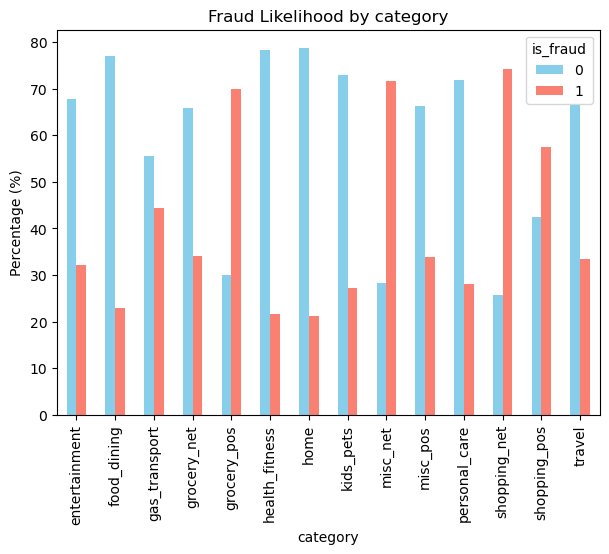

In [122]:
plot_bar(plot_df,"category")

In [123]:

plot_df['dob'] = pd.to_datetime(plot_df['dob'])
today = pd.to_datetime(date.today())
plot_df['age'] = (today - plot_df['dob']).dt.days // 365
plot_df["age"]

1220448    47
505866     65
1194539    49
1214962    40
1110824    59
           ..
392444     53
826020     35
103968     32
144464     72
584542     66
Name: age, Length: 15012, dtype: int64

<Axes: >

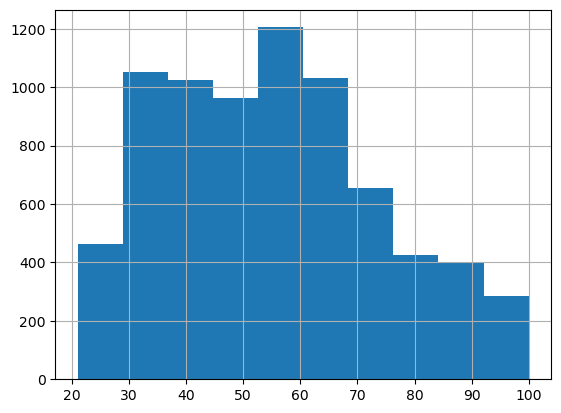

In [124]:
plot_df[plot_df["is_fraud"]==1]["age"].hist()

<Axes: >

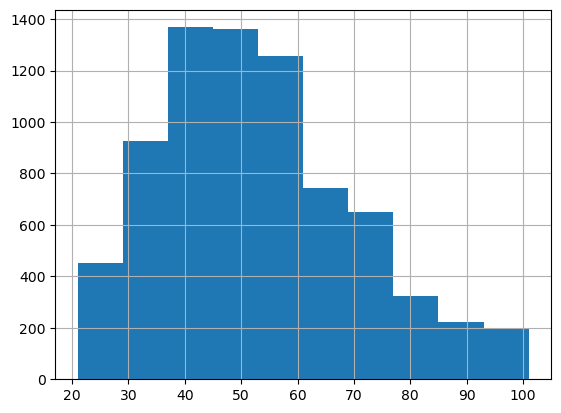

In [125]:
plot_df[plot_df["is_fraud"]==0]["age"].hist()

In [126]:
date_time = pd.to_datetime(plot_df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

plot_df['day_of_week'] = date_time.dt.day_of_week
plot_df['day_of_month'] = date_time.dt.day
plot_df['time_of_day'] = date_time.dt.hour
plot_df['month'] = date_time.dt.month

plot_df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,city_pop,job,dob,is_fraud,distance_km,age,day_of_week,day_of_month,time_of_day,month
1220448,2020-05-25 10:30:35,581508178315,fraud_Hackett-Lueilwitz,grocery_pos,93.67,M,933 Martin Rapids,Desdemona,TX,76445,...,407,Clothing/textile technologist,1978-08-08,0,129.928746,47,0,25,10,5
505866,2019-08-07 17:53:02,676173792455,fraud_Cartwright PLC,kids_pets,33.32,F,07177 William Dale Apt. 547,Santa Monica,CA,90403,...,92043,"Civil engineer, contracting",1961-04-25,0,129.583052,65,2,7,17,8
1194539,2020-05-14 00:05:10,3561212938177173,fraud_Hackett-Lueilwitz,grocery_pos,290.67,M,550 Cunningham Squares,Dadeville,AL,36853,...,8269,Minerals surveyor,1977-01-04,1,103.727016,49,3,14,0,5
1214962,2020-05-23 15:51:08,4810839835482794272,fraud_Adams-Barrows,health_fitness,14.37,F,433 Blake Roads Suite 967,Wheaton,MO,64874,...,760,Production manager,1985-08-31,0,66.331134,40,5,23,15,5
1110824,2020-04-07 01:15:20,4186530744674,fraud_Kiehn Inc,grocery_pos,295.05,F,374 Christopher Ramp Suite 855,Blackville,SC,29817,...,4913,Technical brewer,1966-11-10,1,108.458392,59,1,7,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392444,2019-06-28 22:28:47,5152054598359927,fraud_Schumm PLC,shopping_net,822.01,M,868 Brady Mill Apt. 837,Gretna,LA,70056,...,55581,Biomedical scientist,1972-09-12,1,116.905910,53,4,28,22,6
826020,2019-12-09 18:01:36,4904681492230012,"fraud_Windler, Goodwin and Kovacek",home,3.16,F,574 David Locks Suite 207,Cottekill,NY,12419,...,722,Comptroller,1990-10-19,0,50.729046,35,0,9,18,12
103968,2019-03-01 21:08:40,4855488158131690372,fraud_Hammes-Beatty,kids_pets,44.67,M,25887 Martin Inlet,Graniteville,VT,5654,...,970,Agricultural consultant,1993-09-29,0,114.674398,32,4,1,21,3
144464,2019-03-18 22:24:35,4128027264554082,fraud_Berge-Hills,kids_pets,37.91,M,7507 Larry Passage Suite 859,Mount Perry,OH,43760,...,1831,Barrister's clerk,1953-10-18,0,60.137798,72,0,18,22,3


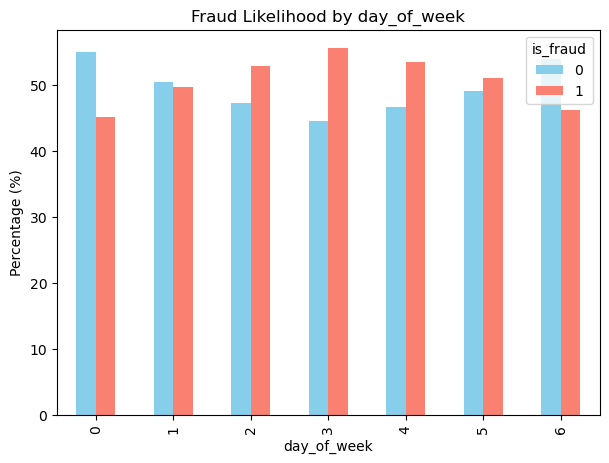

In [129]:
plot_bar(plot_df,"day_of_week")

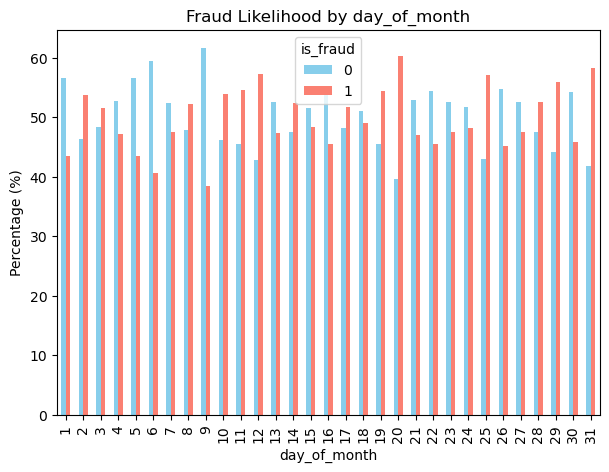

In [130]:
plot_bar(plot_df,"day_of_month")

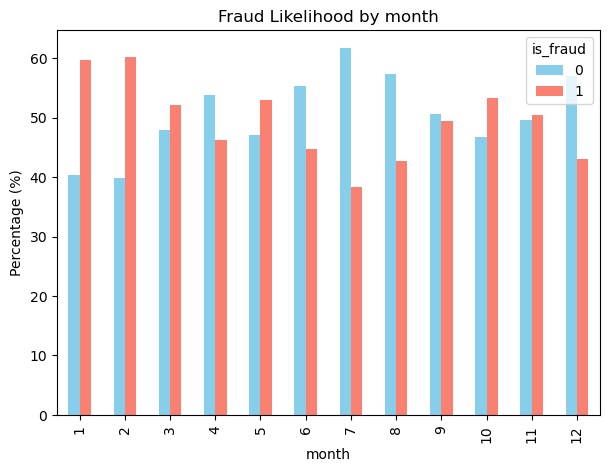

In [131]:
plot_bar(plot_df,"month")

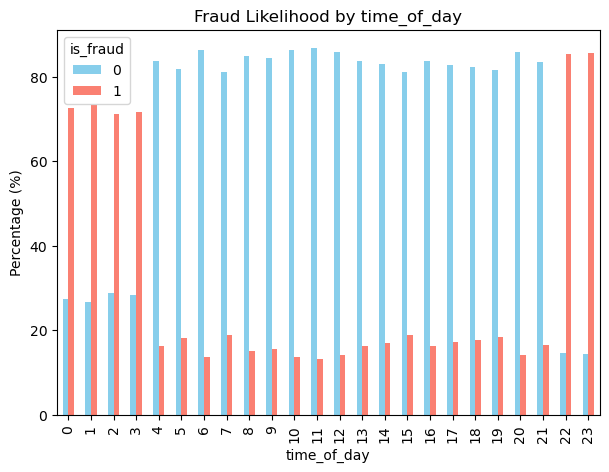

In [132]:
plot_bar(plot_df,"time_of_day")

array([[<Axes: title={'center': 'cc_num'}>,
        <Axes: title={'center': 'amt'}>],
       [<Axes: title={'center': 'zip'}>, <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'city_pop'}>]], dtype=object)

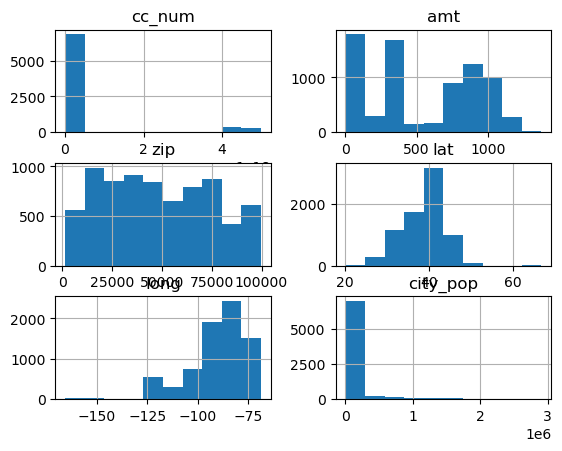

In [133]:
plot_df[plot_df["is_fraud"]==1][['cc_num','amt','zip','lat',"long" ,"city_pop"]].hist()


array([[<Axes: title={'center': 'cc_num'}>,
        <Axes: title={'center': 'amt'}>],
       [<Axes: title={'center': 'zip'}>, <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'city_pop'}>]], dtype=object)

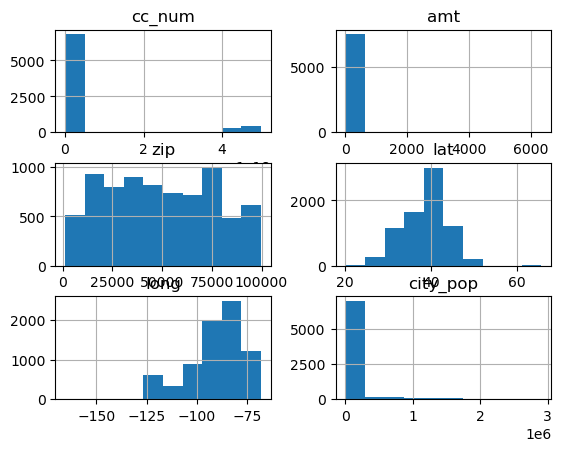

In [134]:
plot_df[plot_df["is_fraud"]==0][['cc_num','amt','zip','lat',"long" ,"city_pop"]].hist()


array([[<Axes: title={'center': 'distance_km'}>]], dtype=object)

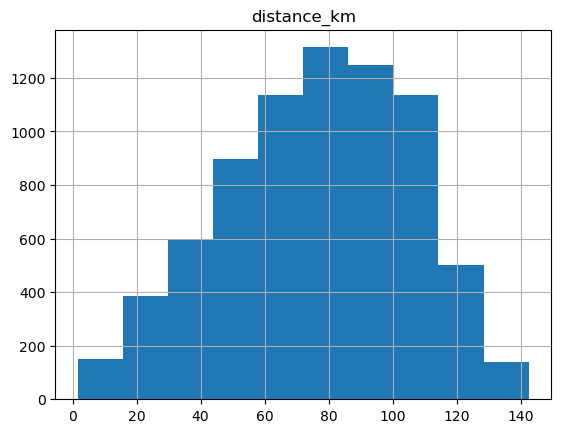

In [135]:
plot_df[plot_df["is_fraud"]==0][["distance_km"]].hist()

array([[<Axes: title={'center': 'distance_km'}>]], dtype=object)

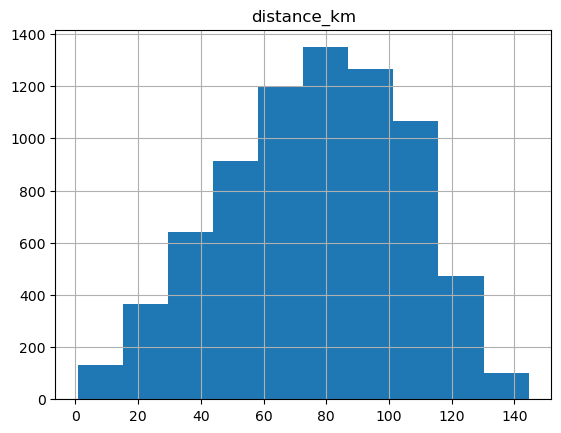

In [136]:
plot_df[plot_df["is_fraud"]==1][["distance_km"]].hist()


In [139]:
data["city"].value_counts()


city
Birmingham     5617
San Antonio    5130
Utica          5105
Phoenix        5075
Meridian       5060
               ... 
Claypool          7
Norfolk           7
Karns City        7
Bruce             7
Streator          7
Name: count, Length: 894, dtype: int64

In [140]:


def get_cramers_v(var1, var2):
    # Build the contingency table
    crosstab = pd.crosstab(var1, var2)
    
    # Get Chi-Square statistic
    chi2 = chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()
    phi2 = chi2 / n
    r, k = crosstab.shape
    
    # Calculate Cramer's V
    return np.sqrt(phi2 / min(k - 1, r - 1))


In [141]:
# 1. Identify your categorical columns
cat_cols = plot_df.select_dtypes(include=['object', 'category']).drop(columns=["trans_date_trans_time"])

cat_cols = pd.concat([cat_cols , pd.DataFrame(plot_df["is_fraud"])] , axis=1).columns



/tmp/ipykernel_3543/1284971011.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = plot_df.select_dtypes(include=['object', 'category']).drop(columns=["trans_date_trans_time"])


In [142]:
# 2. Initialize an empty matrix
v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

# 3. Nested Loop
for col1 in cat_cols:
    for col2 in cat_cols:
        v_matrix.loc[col1, col2] = get_cramers_v(plot_df[col1], plot_df[col2])

# Convert to float for visualization
v_matrix = v_matrix.astype(float)

In [143]:
results = {}
target = 'is_fraud'

for col in cat_cols:
    if col != target:
        results[col] = get_cramers_v(plot_df[col], plot_df[target])

# Convert to a sorted list for easy reading
sorted_features = pd.Series(results).sort_values(ascending=False)
print(sorted_features)

street      0.524024
city        0.497462
merchant    0.448198
category    0.409173
job         0.364336
state       0.106936
gender      0.048541
dtype: float64


<Axes: >

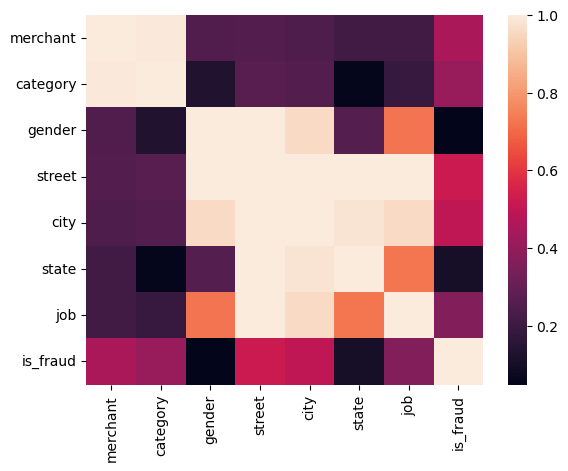

In [144]:


sns.heatmap(v_matrix)


In [145]:
v_matrix

,merchant,category,gender,street,city,state,job,is_fraud
merchant,1.000000,0.994726,0.247645,0.255755,0.244055,0.214042,0.215001,0.448198
category,0.994726,1.000000,0.131469,0.268774,0.256575,0.058805,0.189237,0.409173
gender,0.247645,0.131469,0.999867,1.000000,0.957848,0.258923,0.723889,0.048541
street,0.255755,0.268774,1.000000,1.000000,1.000000,1.000000,1.000000,0.524024
city,0.244055,0.256575,0.957848,1.000000,1.000000,0.978812,0.955758,0.497462
state,0.214042,0.058805,0.258923,1.000000,0.978812,1.000000,0.725265,0.106936
job,0.215001,0.189237,0.723889,1.000000,0.955758,0.725265,1.000000,0.364336
is_fraud,0.448198,0.409173,0.048541,0.524024,0.497462,0.106936,0.364336,0.999867


merchant and category are highly correlated , favor category for more information with less labels 

In [146]:
gender_diversity = plot_df.groupby('street')['gender'].nunique()
print(gender_diversity.value_counts())

gender
1    977
Name: count, dtype: int64


street and gender have a perfect cramer's v score , and inspecting the data reveals there is only 1 gender per street in this dataset 
conclusion : street should be dropped 

street, city, state, zip, job should be dropped because of perfect correlation , they essentially act as ids for each other 

categorical features left : category ,gender

In [147]:
dummies = pd.get_dummies(plot_df["category"], prefix="category",dtype=int)
g_dummies = pd.get_dummies(plot_df["gender"], prefix="gender",dtype=int)
df = pd.concat([plot_df , dummies], axis=1)
df = df.drop(columns=["merchant","street","city","state","job","cc_num","city_pop","trans_date_trans_time","zip","lat","long","dob","category","gender"])
df.dtypes

amt                        float64
is_fraud                     int64
distance_km                float64
age                          int64
day_of_week                  int32
day_of_month                 int32
time_of_day                  int32
month                        int32
category_entertainment       int64
category_food_dining         int64
category_gas_transport       int64
category_grocery_net         int64
category_grocery_pos         int64
category_health_fitness      int64
category_home                int64
category_kids_pets           int64
category_misc_net            int64
category_misc_pos            int64
category_personal_care       int64
category_shopping_net        int64
category_shopping_pos        int64
category_travel              int64
dtype: object

In [148]:

# Identify which columns are categorical (True/False list)
# Assume X is your DataFrame
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# Mark integer/bool columns as discrete and float columns as continuous
discrete_mask = X.dtypes.apply(lambda dt: pd.api.types.is_integer_dtype(dt) or pd.api.types.is_bool_dtype(dt)).to_numpy()

# Run the calculation
scores = mutual_info_classif(X, y, discrete_features=discrete_mask)

# Create a ranking
mi_results = pd.Series(scores, index=X.columns).sort_values(ascending=False)

mi_results

amt                        0.460007
time_of_day                0.223617
category_shopping_net      0.022200
age                        0.017553
category_grocery_pos       0.016133
category_home              0.011604
category_misc_net          0.009069
month                      0.008166
category_health_fitness    0.007319
category_food_dining       0.007066
category_kids_pets         0.006757
category_personal_care     0.005454
day_of_month               0.005303
category_entertainment     0.003329
category_misc_pos          0.002774
day_of_week                0.002645
category_grocery_net       0.001383
category_travel            0.001324
category_shopping_pos      0.001199
category_gas_transport     0.000651
distance_km                0.000000
dtype: float64

In [149]:
df

,amt,is_fraud,distance_km,age,day_of_week,day_of_month,time_of_day,month,category_entertainment,category_food_dining,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
1220448,93.67,0,129.928746,47,0,25,10,5,0,0,...,1,0,0,0,0,0,0,0,0,0
505866,33.32,0,129.583052,65,2,7,17,8,0,0,...,0,0,0,1,0,0,0,0,0,0
1194539,290.67,1,103.727016,49,3,14,0,5,0,0,...,1,0,0,0,0,0,0,0,0,0
1214962,14.37,0,66.331134,40,5,23,15,5,0,0,...,0,1,0,0,0,0,0,0,0,0
1110824,295.05,1,108.458392,59,1,7,1,4,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392444,822.01,1,116.905910,53,4,28,22,6,0,0,...,0,0,0,0,0,0,0,1,0,0
826020,3.16,0,50.729046,35,0,9,18,12,0,0,...,0,0,1,0,0,0,0,0,0,0
103968,44.67,0,114.674398,32,4,1,21,3,0,0,...,0,0,0,1,0,0,0,0,0,0
144464,37.91,0,60.137798,72,0,18,22,3,0,0,...,0,0,0,1,0,0,0,0,0,0


In [150]:
plot_df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,city_pop,job,dob,is_fraud,distance_km,age,day_of_week,day_of_month,time_of_day,month
1220448,2020-05-25 10:30:35,581508178315,fraud_Hackett-Lueilwitz,grocery_pos,93.67,M,933 Martin Rapids,Desdemona,TX,76445,...,407,Clothing/textile technologist,1978-08-08,0,129.928746,47,0,25,10,5
505866,2019-08-07 17:53:02,676173792455,fraud_Cartwright PLC,kids_pets,33.32,F,07177 William Dale Apt. 547,Santa Monica,CA,90403,...,92043,"Civil engineer, contracting",1961-04-25,0,129.583052,65,2,7,17,8
1194539,2020-05-14 00:05:10,3561212938177173,fraud_Hackett-Lueilwitz,grocery_pos,290.67,M,550 Cunningham Squares,Dadeville,AL,36853,...,8269,Minerals surveyor,1977-01-04,1,103.727016,49,3,14,0,5
1214962,2020-05-23 15:51:08,4810839835482794272,fraud_Adams-Barrows,health_fitness,14.37,F,433 Blake Roads Suite 967,Wheaton,MO,64874,...,760,Production manager,1985-08-31,0,66.331134,40,5,23,15,5
1110824,2020-04-07 01:15:20,4186530744674,fraud_Kiehn Inc,grocery_pos,295.05,F,374 Christopher Ramp Suite 855,Blackville,SC,29817,...,4913,Technical brewer,1966-11-10,1,108.458392,59,1,7,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392444,2019-06-28 22:28:47,5152054598359927,fraud_Schumm PLC,shopping_net,822.01,M,868 Brady Mill Apt. 837,Gretna,LA,70056,...,55581,Biomedical scientist,1972-09-12,1,116.905910,53,4,28,22,6
826020,2019-12-09 18:01:36,4904681492230012,"fraud_Windler, Goodwin and Kovacek",home,3.16,F,574 David Locks Suite 207,Cottekill,NY,12419,...,722,Comptroller,1990-10-19,0,50.729046,35,0,9,18,12
103968,2019-03-01 21:08:40,4855488158131690372,fraud_Hammes-Beatty,kids_pets,44.67,M,25887 Martin Inlet,Graniteville,VT,5654,...,970,Agricultural consultant,1993-09-29,0,114.674398,32,4,1,21,3
144464,2019-03-18 22:24:35,4128027264554082,fraud_Berge-Hills,kids_pets,37.91,M,7507 Larry Passage Suite 859,Mount Perry,OH,43760,...,1831,Barrister's clerk,1953-10-18,0,60.137798,72,0,18,22,3


In [151]:


ct = ColumnTransformer(
    [("low_card_cat",OneHotEncoder(),["category","gender","state"]),
     ("high_card_cat",JamesSteinEncoder(),["merchant","street","city","job"])
     ],remainder="passthrough"
)



final_test_df = ct.fit_transform(plot_df.drop(columns=["is_fraud","trans_date_trans_time","dob"]),plot_df["is_fraud"])


In [152]:
final_test_df

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 277578 stored elements and shape (15012, 83)>

In [153]:



rf = RandomForestClassifier()
rf.fit(final_test_df,plot_df["is_fraud"])




,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [154]:
data = pd.read_csv("./fraudTest.csv", index_col=0)

In [155]:
data

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [156]:
date_time = pd.to_datetime(data['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

data['day_of_week'] = date_time.dt.day_of_week
data['day_of_month'] = date_time.dt.day
data['time_of_day'] = date_time.dt.hour
data['month'] = date_time.dt.month


data['dob'] = pd.to_datetime(data['dob'])
today = pd.to_datetime(date.today())
data['age'] = (today - data['dob']).dt.days // 365
data["age"]


X_test = data.drop(columns=["is_fraud", "trans_date_trans_time", "dob"])
y_test = data["is_fraud"]

X_test = ct.transform(X_test)

ValueError: columns are missing: {'distance_km'}

In [ ]:
y_test

0         0
1         0
2         0
3         0
4         0
         ..
555714    0
555715    0
555716    0
555717    0
555718    0
Name: is_fraud, Length: 555719, dtype: int64

In [ ]:
preds = rf.predict(X_test)

In [ ]:
rf.score(X_test,y_test)

0.969839073344622

In [ ]:

# 1. Get feature names from the transformer
feature_names = ct.get_feature_names_out()

# 2. Get importance scores from the model
importances = rf.feature_importances_

# 3. Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

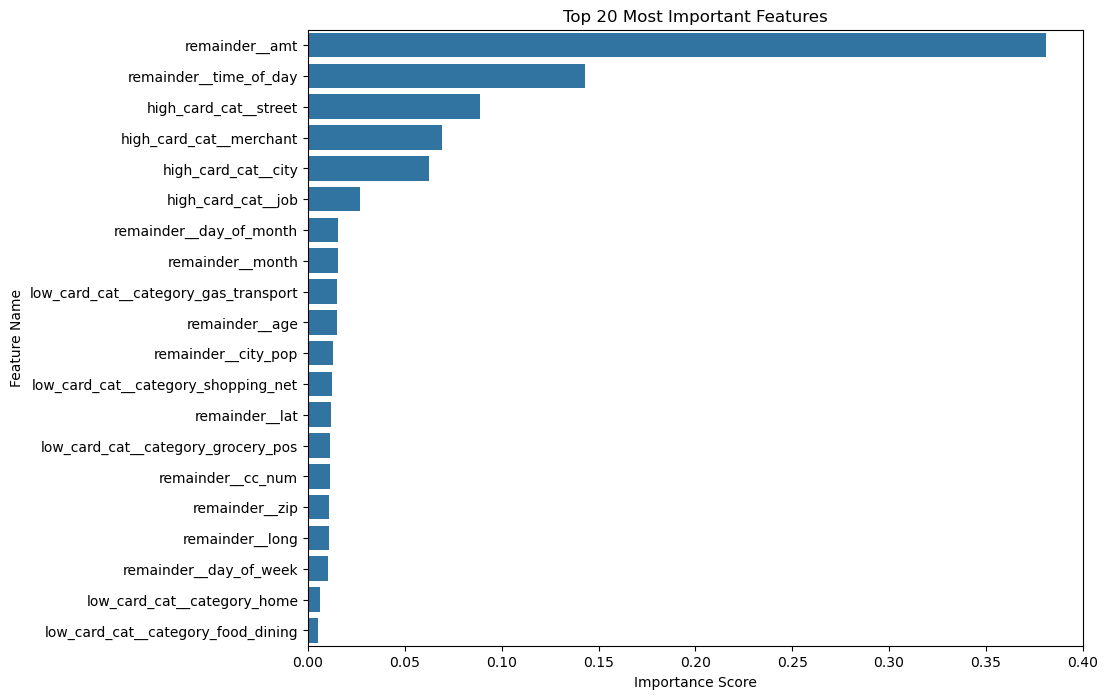

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(20)) # Show top 20
plt.title('Top 20 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()